# Agent Memory Types with LangGraph + SQLite

Memory is what turns a stateless LLM call into an **agent that remembers**. In this notebook we implement and contrast the three memory types every production agent needs, all backed by a single **SQLite** database and orchestrated with **LangGraph**.

| Memory Type | Scope | Lifetime | Typical Content | LangGraph Mechanism |
|---|---|---|---|---|
| **Short-Term (Working)** | Single thread / conversation | Session | Recent messages, tool results | `SqliteSaver` checkpointer |
| **Long-Term (Semantic)** | Across all threads for a user | Persistent | User facts, preferences, profile | SQLite table + tools |
| **Episodic** | Across all threads for a user | Persistent | Past events, task-outcome pairs | SQLite table + tools |

### Mental Model

- **Short-term** = what you remember *during* a conversation (like RAM).
- **Long-term (semantic)** = facts you *know* about the user ("Alice lives in Berlin", "prefers short answers").
- **Episodic** = experiences you *lived through* ("last Tuesday I helped Alice debug a pandas merge — she liked the code-first approach").

All three are persisted to `agent_memory.db` so they survive process restarts.

## Setup

We use the project's `helpers.get_llm` factory (platform-aware — Databricks on macOS, Groq on Windows) and LangGraph's built-in `SqliteSaver` for checkpointing.

In [16]:
# ============ IMPORTS ============
import os
import sys
import json
import uuid
import sqlite3
from datetime import datetime
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.sqlite import SqliteSaver

# Local helpers
sys.path.append(os.path.abspath("../../.."))
from helpers import get_llm

from dotenv import load_dotenv
load_dotenv()

print("Imports OK")

Imports OK


In [17]:
# ============ LLM INITIALIZATION ============
# Uses platform defaults: Databricks on macOS, Groq on Windows.
llm = get_llm()

LLM initialized: databricks-claude-opus-4-6 (via databricks)


In [18]:
# ============ SQLITE DATABASE SETUP ============
# One file holds all three memory types in separate tables.
DB_PATH = "agent_memory.db"

def init_memory_db(path: str = DB_PATH) -> None:
    """Create long-term and episodic tables. Short-term uses SqliteSaver's own schema."""
    with sqlite3.connect(path) as con:
        con.executescript(
            """
            CREATE TABLE IF NOT EXISTS semantic_memory (
                id         TEXT PRIMARY KEY,
                user_id    TEXT NOT NULL,
                fact       TEXT NOT NULL,
                created_at TEXT NOT NULL
            );

            CREATE TABLE IF NOT EXISTS episodic_memory (
                id         TEXT PRIMARY KEY,
                user_id    TEXT NOT NULL,
                task       TEXT NOT NULL,
                outcome    TEXT NOT NULL,
                feedback   TEXT,
                created_at TEXT NOT NULL
            );

            CREATE INDEX IF NOT EXISTS idx_sem_user ON semantic_memory(user_id);
            CREATE INDEX IF NOT EXISTS idx_epi_user ON episodic_memory(user_id);
            """
        )

init_memory_db()
print(f"DB ready at: {os.path.abspath(DB_PATH)}")

DB ready at: /Users/sourav.banerjee/Documents/2. Codebases/2. AI_Engineering/LangGraph_Demystified/02_Core_Capabilities/01_Memory/memory/agent_memory.db


## 1. Short-Term Memory — Thread-Scoped Conversation

Short-term memory is the conversation history within a single `thread_id`. LangGraph persists it automatically via a **checkpointer**. We use `SqliteSaver` so checkpoints land in `agent_memory.db` and survive restarts.

**Key property**: bounded by the thread. Start a new `thread_id` → agent has no short-term context.

```
thread_id="chat-1"  -->  full history A
thread_id="chat-2"  -->  full history B  (isolated)
```

### ⚠️ "Short-term" here means *scope*, not *lifetime*

Classical theory says short-term memory should be **ephemeral** (RAM-like, dies with the session). LangGraph relaxes that: in its model, "short-term" is defined by **scope** (one `thread_id`), not by lifetime. The checkpointer backend decides durability:

| Checkpointer | Lifetime | Matches classical theory? |
|---|---|---|
| `MemorySaver` | Process-only — dies on restart | ✅ Yes (true ephemeral) |
| `SqliteSaver` (used here) | Persisted to disk | ❌ No — survives restarts |
| `PostgresSaver` | Persisted to a managed DB | ❌ No — production durability |

Why use `SqliteSaver` in this tutorial? **Resumability** (kernel crashes don't lose your conversation), **inspectability** (you can open `agent_memory.db` and see checkpoints), and **production realism** (the same pattern swaps to Postgres in prod). The thread-isolation behavior is identical across all three — only durability changes.

If you want strict textbook short-term behavior, swap `SqliteSaver` for `MemorySaver`.

In [19]:
# ============ BUILD A SIMPLE CHAT GRAPH ============
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

def chat_node(state: ChatState) -> ChatState:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(ChatState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# SqliteSaver persists each node-step checkpoint to disk.
stm_conn = sqlite3.connect(DB_PATH, check_same_thread=False)
short_term = SqliteSaver(stm_conn)
chat_agent = builder.compile(checkpointer=short_term)
print("Short-term-memory agent compiled.")

Short-term-memory agent compiled.


In [20]:
# ============ DEMO: THREAD A REMEMBERS ITSELF ============
cfg_a = {"configurable": {"thread_id": "thread-A"}}

chat_agent.invoke({"messages": [HumanMessage("My favorite color is teal.")]}, cfg_a)
out = chat_agent.invoke({"messages": [HumanMessage("What color did I just say?")]}, cfg_a)
print("Thread A reply:", out["messages"][-1].content)

Thread A reply: You said your favorite color is **teal**! 😊


In [21]:
# ============ DEMO: THREAD B IS ISOLATED ============
cfg_b = {"configurable": {"thread_id": "thread-B"}}
out = chat_agent.invoke({"messages": [HumanMessage("What color did I say earlier?")]}, cfg_b)
print("Thread B reply:", out["messages"][-1].content)
# --> Agent doesn't know. Short-term memory is scoped to a single thread.

Thread B reply: Looking at our conversation, you haven't mentioned any specific color. Your messages so far have only asked "What color did I say earlier?" I don't have any prior context beyond what's shown in this conversation. 

Would you like to tell me a color now? 😊


In [22]:
with sqlite3.connect(DB_PATH) as con:
    rows = con.execute(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
    ).fetchall()
    for (name,) in rows:
        print(name)

checkpoints
episodic_memory
semantic_memory
writes


In [23]:
with sqlite3.connect(DB_PATH) as con:
    rows = con.execute(
        "SELECT thread_id, checkpoint_id FROM checkpoints LIMIT 10"
    ).fetchall()
    for r in rows:
        print(r)


('alice-session-1', '1f140e08-60a8-694a-bfff-265cc6d4dc55')
('alice-session-1', '1f140e08-60aa-6c40-8000-de65f6054062')
('alice-session-1', '1f140e08-bb7a-6c7e-8001-b79228462b74')
('alice-session-1', '1f140e08-bb7c-6808-8002-41867f2f7632')
('thread-A', '1f140dfe-dea4-6114-bfff-ec490c5e2905')
('thread-A', '1f140dfe-dea5-6d02-8000-ed24660c26d1')
('thread-A', '1f140dff-048b-6c9c-8001-12711e997d42')
('thread-A', '1f140dff-049d-6b86-8002-8bdb1d01db10')
('thread-A', '1f140dff-049f-62a6-8003-ea937873aef1')
('thread-A', '1f140dff-1723-6620-8004-05e31223aa6a')


## 2. Long-Term (Semantic) Memory — Facts About the User

Semantic memory stores **durable facts** about a user that should be available across every conversation. Examples:
- "User's name is Alice"
- "Prefers TypeScript over JavaScript"
- "Lives in Berlin, timezone CET"

We model it as a SQLite table keyed by `user_id`, and expose it to the agent via two tools: `save_fact` and `recall_facts`. The agent itself decides when to write and read.

In [24]:
# ============ SEMANTIC MEMORY: SQL HELPERS ============
def sem_save(user_id: str, fact: str) -> str:
    fid = str(uuid.uuid4())
    with sqlite3.connect(DB_PATH) as con:
        con.execute(
            "INSERT INTO semantic_memory (id, user_id, fact, created_at) VALUES (?, ?, ?, ?)",
            (fid, user_id, fact, datetime.utcnow().isoformat()),
        )
    return fid

def sem_recall(user_id: str) -> list[str]:
    with sqlite3.connect(DB_PATH) as con:
        rows = con.execute(
            "SELECT fact FROM semantic_memory WHERE user_id = ? ORDER BY created_at",
            (user_id,),
        ).fetchall()
    return [r[0] for r in rows]

## 3. Episodic Memory — Past Events & Outcomes

Episodic memory records **what happened** in past interactions — the task, the outcome, optional user feedback. It lets the agent learn from experience ("last time we tried approach X it failed; try Y first").

Schema:

| Field | Meaning |
|---|---|
| `task`     | What the user asked for |
| `outcome`  | What the agent did / delivered |
| `feedback` | Optional user reaction (thumbs up / correction) |

Distinction from semantic memory: semantic = *timeless facts*; episodic = *time-stamped experiences*.

In [25]:
# ============ EPISODIC MEMORY: SQL HELPERS ============
def epi_save(user_id: str, task: str, outcome: str, feedback: str | None = None) -> str:
    eid = str(uuid.uuid4())
    with sqlite3.connect(DB_PATH) as con:
        con.execute(
            "INSERT INTO episodic_memory (id, user_id, task, outcome, feedback, created_at)"
            " VALUES (?, ?, ?, ?, ?, ?)",
            (eid, user_id, task, outcome, feedback, datetime.utcnow().isoformat()),
        )
    return eid

def epi_recall(user_id: str, limit: int = 5) -> list[dict]:
    with sqlite3.connect(DB_PATH) as con:
        rows = con.execute(
            "SELECT task, outcome, feedback, created_at FROM episodic_memory"
            " WHERE user_id = ? ORDER BY created_at DESC LIMIT ?",
            (user_id, limit),
        ).fetchall()
    return [
        {"task": t, "outcome": o, "feedback": f, "created_at": c}
        for (t, o, f, c) in rows
    ]

## 4. Expose Long-Term & Episodic Memory as Tools

Tools let the LLM drive memory reads and writes itself. The `user_id` is injected at the node level (not exposed to the model) so users can't spoof each other's memory.

In [26]:
# ============ MEMORY TOOLS (user_id injected by the agent node) ============
# A simple per-invocation context. In production use contextvars.
_CURRENT_USER: dict = {"id": None}

@tool
def save_user_fact(fact: str) -> str:
    """Persist a durable fact about the user (name, preference, profile detail)."""
    sem_save(_CURRENT_USER["id"], fact)
    return f"Saved fact: {fact}"

@tool
def recall_user_facts() -> str:
    """Return every stored fact about the current user."""
    facts = sem_recall(_CURRENT_USER["id"])
    return json.dumps(facts) if facts else "No facts stored yet."

@tool
def save_episode(task: str, outcome: str, feedback: str = "") -> str:
    """Record an interaction episode (task performed and its outcome)."""
    epi_save(_CURRENT_USER["id"], task, outcome, feedback or None)
    return "Episode recorded."

@tool
def recall_recent_episodes(limit: int = 5) -> str:
    """Return recent past interactions (tasks + outcomes) for this user."""
    eps = epi_recall(_CURRENT_USER["id"], limit=limit)
    return json.dumps(eps, indent=2) if eps else "No past episodes."

memory_tools = [save_user_fact, recall_user_facts, save_episode, recall_recent_episodes]

## 5. Build the Memory-Aware Agent

The agent combines:
- **Short-term** via the `SqliteSaver` checkpointer (per-thread).
- **Long-term + episodic** via tools that the LLM calls as needed.
- A system prompt that **preloads** stored facts + recent episodes, so the model has context *before* its first token.

This is the standard layered pattern: fast context in the prompt, on-demand retrieval via tools.

In [27]:
# ============ MEMORY-AWARE AGENT GRAPH ============
llm_with_tools = llm.bind_tools(memory_tools)

SYSTEM_TEMPLATE = """You are a helpful assistant with persistent memory.

Known facts about this user (semantic memory):
{facts}

Recent past interactions (episodic memory):
{episodes}

Rules:
- When the user reveals a durable fact (name, preferences, context), call `save_user_fact`.
- After completing a substantive task, call `save_episode` with a short task/outcome summary.
- Use `recall_user_facts` / `recall_recent_episodes` only if the preloaded context is insufficient.
"""

def agent_node(state: MessagesState, config: RunnableConfig) -> dict:
    user_id = config["configurable"]["user_id"]
    _CURRENT_USER["id"] = user_id

    facts = sem_recall(user_id) or ["(none)"]
    episodes = epi_recall(user_id, limit=3) or [{"task": "(none)", "outcome": ""}]
    system = SystemMessage(
        SYSTEM_TEMPLATE.format(
            facts="\n".join(f"- {f}" for f in facts),
            episodes="\n".join(
                f"- {e['task']} -> {e['outcome']}" for e in episodes
            ),
        )
    )
    response = llm_with_tools.invoke([system] + state["messages"])
    return {"messages": [response]}

mem_builder = StateGraph(MessagesState)
mem_builder.add_node("agent", agent_node)
mem_builder.add_node("tools", ToolNode(memory_tools))
mem_builder.add_edge(START, "agent")
mem_builder.add_conditional_edges("agent", tools_condition, ["tools", END])
mem_builder.add_edge("tools", "agent")

mem_agent = mem_builder.compile(checkpointer=short_term)
print("Memory-aware agent compiled.")

Memory-aware agent compiled.


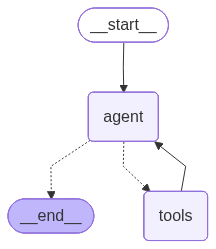

In [28]:
# ============ VISUALIZE GRAPH ============
try:
    from IPython.display import Image, display
    display(Image(mem_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Skipping viz:", e)

## 6. End-to-End Demo

We run two conversations on different `thread_id`s for the same `user_id` and verify that:

1. The **new thread has no short-term context**.
2. The agent still **remembers facts** saved in the prior thread (long-term).
3. Past **episodes** are available as retrieval context.

In [29]:
# ============ CONVERSATION 1: USER TEACHES THE AGENT ============
USER_ID = "user-alice"
cfg1 = {"configurable": {"user_id": USER_ID, "thread_id": "alice-session-1"}}

turns = [
    "Hi, I'm Alice. I work as a data engineer and prefer Python over Scala.",
    "Please help me outline a 3-step plan to migrate a Spark job from Scala to PySpark.",
]
for t in turns:
    out = mem_agent.invoke({"messages": [HumanMessage(t)]}, cfg1)
    print("USER:", t)
    print("AGENT:", out["messages"][-1].content[:400], "\n---")

/var/folders/b_/0hx_r16d2v712fg4k7y_rh140000gp/T/ipykernel_91777/1044027379.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  (fid, user_id, fact, datetime.utcnow().isoformat()),


USER: Hi, I'm Alice. I work as a data engineer and prefer Python over Scala.
AGENT: I've got all your details saved, Alice! Here's what I know about you:

- **Name:** Alice
- **Role:** Data Engineer
- **Language preference:** Python over Scala 🐍

How can I help you today? Whether it's data pipelines, Python scripting, or anything else — I'm here for you! 
---


/var/folders/b_/0hx_r16d2v712fg4k7y_rh140000gp/T/ipykernel_91777/1168409036.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  (eid, user_id, task, outcome, feedback, datetime.utcnow().isoformat()),


USER: Please help me outline a 3-step plan to migrate a Spark job from Scala to PySpark.
AGENT: Let me know if you'd like to dig into any specific step — happy to help! 😊 
---


In [30]:
# ============ INSPECT THE SQLITE MEMORY DIRECTLY ============
print("Semantic facts:")
for f in sem_recall(USER_ID):
    print(" -", f)

print("\nEpisodes:")
for e in epi_recall(USER_ID):
    print(" -", e)

Semantic facts:
 - User's name is Alice.
 - Alice works as a data engineer.
 - Alice prefers Python over Scala.

Episodes:
 - {'task': 'Outlined a 3-step plan to migrate a Spark job from Scala to PySpark.', 'outcome': 'Provided a plan covering: (1) Audit & map existing Scala job, (2) Rewrite in PySpark & adapt code, (3) Test, benchmark & deploy. Included tips on pandas_udf and Spark Connect.', 'feedback': None, 'created_at': '2026-04-25T19:57:10.299881'}


In [31]:
# ============ CONVERSATION 2: BRAND-NEW THREAD, SAME USER ============
# Short-term memory is empty here -> the only way the agent knows Alice
# is via long-term (semantic) + episodic memory loaded in the system prompt.
cfg2 = {"configurable": {"user_id": USER_ID, "thread_id": "alice-session-2"}}

out = mem_agent.invoke(
    {"messages": [HumanMessage("What's my name and which language do I prefer?")]},
    cfg2,
)
print("AGENT:", out["messages"][-1].content)

AGENT: Based on what I know about you:

- **Name:** Alice
- **Preferred language:** Python (over Scala)

Is there anything else you'd like to know or discuss? 😊


In [32]:
# ============ ISOLATION CHECK: A DIFFERENT USER SEES NOTHING ============
cfg3 = {"configurable": {"user_id": "user-bob", "thread_id": "bob-1"}}
out = mem_agent.invoke(
    {"messages": [HumanMessage("What do you know about me?")]},
    cfg3,
)
print("AGENT:", out["messages"][-1].content)

AGENT: It looks like I don't have any information about you yet — this appears to be our first interaction! My memory is a clean slate. 😊

Feel free to tell me about yourself — your name, interests, what you're working on, or any preferences you'd like me to remember. I'll store those details so I can provide a more personalized experience in future conversations!


## Summary

- **Short-term memory** is handled transparently by LangGraph's `SqliteSaver` checkpointer — bounded to a `thread_id`.
- **Long-term (semantic) memory** is a simple SQL table of durable user facts, scoped by `user_id`, exposed as tools.
- **Episodic memory** is a SQL table of past task/outcome pairs — lets the agent learn from prior interactions.
- Preloading facts + recent episodes into the system prompt gives the model **free context**, while tools enable deeper lookups on demand.

### Next steps

- Add **semantic search** over facts/episodes with `get_embeddings` + `sqlite-vec` or `pgvector` for scale.
- Add a **reflection step** that summarizes long conversations into new facts/episodes (memory consolidation).
- Swap `SqliteSaver` for `PostgresSaver` and `PostgresStore` when moving from notebook to production.